In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col


import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import to_rgba

import numpy as np
from scipy.stats import t
from scipy.stats import norm
from scipy.stats import ttest_rel
from numpy.linalg import inv
import warnings
import roman


sns.set_style('whitegrid')
warnings. filterwarnings('ignore')

import rpy2
from rpy2 import robjects
import rpy2.robjects as ro
from rpy2.robjects.packages import importr, data
from rpy2.rinterface_lib.callbacks import logger as rpy2_logger
import logging
rpy2_logger.setLevel(logging.ERROR)

utils = importr('utils')
base = importr('base')
oaxaca = importr('oaxaca')

def convert_pvalue(test, pvalue):
    if pvalue <= 0.01:
        return "${:.3f}".format(test) + '^{***}$'
    elif pvalue <= 0.05:
        return "${:.3f}".format(test) + '^{**}$'
    elif pvalue <= 0.1:
        return "${:.3f}".format(test) + '^{*}$'
    return "${:.3f}$".format(test)


def update_tab(x):
    mean = x[0]
    std = x[1]
    zval = mean/std
    def convert_pvalue(mean, std, pvalue):
        if pvalue <= 0.01:
            significance = ' ^{***}' 
        elif pvalue <= 0.05:
            significance = ' ^{**}'
        elif pvalue <= 0.1:
            significance = ' ^{*}'
        else: 
            significance = ''
        return ['${:.3f}{:s}$'.format(mean, significance), '$({:.3f})$'.format(std)]# "$\\begin{matrix}" + "{:.3f}{:s} \\\\ ({:.3f})".format(mean, significance, std) + "\end{matrix}$"
    return convert_pvalue(mean, std, 2*norm.cdf(-abs(zval)))


def share_gap(x):
    endow = float(x['endowments'].split(" ")[0].replace("$", ""))
    coeff = float(x['coefficients'].split(" ")[0].replace("$", ""))
    inter = float(x['interaction'].split(" ")[0].replace("$", ""))
    total = endow + coeff + inter
    return ['{:.2f}\%'.format(100* (endow/total)), 
            '{:.2f}\%'.format(100* (coeff/total)),
            '{:.2f}\%'.format(100* (inter/total))]


def joinit(iterable, delimiter):
    it = iter(iterable)
    yield next(it)
    for x in it:
        yield delimiter
        yield x

def update_results(resulst_dict_threefold, ind, char, variables_dict, base=[], part='all'):
    columns_names= ['coef(endowments)', 'se(endowments)', 
                    'coef(coefficients)', 'se(coefficients)', 
                    'coef(interaction)', 'se(interaction)']


    df_overall = pd.DataFrame(np.array([resulst_dict_threefold['overall']]), columns = columns_names)
    df_overall['endowments'] = df_overall[['coef(endowments)', 'se(endowments)']].apply(update_tab, axis=1)
    df_overall['coefficients'] = df_overall[['coef(coefficients)', 'se(coefficients)']].apply(update_tab, axis=1)
    df_overall['interaction'] = df_overall[['coef(interaction)', 'se(interaction)']].apply(update_tab, axis=1)
    df_overall = df_overall[['endowments', 'coefficients', 'interaction']]
    df_overall = pd.concat([df_overall[col].explode(ignore_index=True) for col in df_overall], axis="columns")
    df_overall.index = ['Agregate decomposition', '']
    
    df_overall_shared = df_overall.loc['Agregate decomposition'].to_frame().T.apply(lambda x: share_gap(x), axis=1)
    df_overall.loc[len(df_overall.index)] = df_overall_shared.values[0]
    df_overall.loc[len(df_overall.index)] = ['','','']
    df_overall.index = ['Agregate decomposition', '', 'Share of the gap', 'Detailed decomposition']
    
    df_variables = pd.DataFrame(np.array(resulst_dict_threefold['variables']), 
                        index=['constant'] + ind + char + base,
                        columns = columns_names)
    df_variables = df_variables.rename(index=variables_dict)

    df_variables['endowments'] = df_variables[['coef(endowments)', 'se(endowments)']].apply(update_tab, axis=1)
    df_variables['coefficients'] = df_variables[['coef(coefficients)', 'se(coefficients)']].apply(update_tab, axis=1)
    df_variables['interaction'] = df_variables[['coef(interaction)', 'se(interaction)']].apply(update_tab, axis=1)
    df_variables = df_variables[['endowments', 'coefficients', 'interaction']]
    old_index = df_variables.index
    df_variables = pd.concat([df_variables[col].explode(ignore_index=True) for col in df_variables], axis="columns")
    new_index = [""] * (2 * len(old_index) - 1)
    
    df_variables.index = list(joinit(old_index, '')) + ['']
        
    df_results = pd.concat([df_overall, df_variables])
    if part == 'overall':
        return df_overall
    elif part == 'variables':
        return df_variables
    else:
        return df_results

In [11]:
df_dna = pd.read_csv("../Data/CMS-raw/dna.csv")
df_household = pd.read_csv("../Data/CMS-raw/household_composition_all-regions.csv")
pd.df_household




,ID,ZoneID,StateID,LgaID,LocalityID,EnumerationID,HouseID,Individual_family_code,Name_hhd_member,Sex,...,Age_checked,Marital_status,Marital_status_attribute,Edu_years,hhd_Relation,Occupation_Y_N,Main_occupation,Secondary_occupation,fam_lab_contribution,Proportion_Check
0,1,1,11,1110,11101,111011,1110112,2,Cathrina Bagi,Female,...,Yes,Other,not specified,12.0,Spouse,No,Farming(crop+livestock),NaN,100%,Yes
1,2,1,11,1110,11101,111011,1110112,3,Naedogbo Bagi,Female,...,Yes,Other,not specified,12.0,Spouse,No,Farming(crop+livestock),NaN,100%,Yes
2,3,1,11,1110,11101,111011,1110112,4,Titus Bagi,Male,...,Yes,Married,Living with spouse(s),14.0,Son or Daughter,Yes,Salaried employment,Farming(crop+livestock),50%,Yes
3,4,1,11,1110,11101,111011,1110112,5,Sunday Bagi,Male,...,Yes,Married,Living with spouse(s),16.0,Son or Daughter,Yes,Salaried employment,Farming(crop+livestock),50%,Yes
4,5,1,11,1110,11101,111011,1110112,6,Timothy Bagi,Male,...,Yes,Married,Living with spouse(s),15.0,Son or Daughter,Yes,Self employed off farm,Farming(crop+livestock),50%,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11149,11150,4,43,4316,43162,431622,4316224,5,Festus Okoro,Male,...,Yes,Single,NaN,12.0,Spouse,No,Farming(crop+livestock),NaN,100%,Yes
11150,11151,4,43,4316,43162,431622,4316224,3,Chukwu Okoro,Male,...,Yes,Single,NaN,6.0,Son or Daughter,No,School/college child,NaN,10%,Yes
11151,11152,4,43,4316,43162,431622,4316224,1,Robinson Okoro,Male,...,Yes,Married,Living with spouse(s),6.0,Household head,No,Farming(crop+livestock),NaN,100%,Yes
11152,11153,4,43,4316,43162,431622,4316224,2,Victoria Okoro,Female,...,Yes,Married,Living with spouse(s),6.0,Spouse,No,Farming(crop+livestock),NaN,100%,Yes


In [10]:
df_M_raw = pd.read_stata('../Data/drive-download-20231006T131216Z-001/CMS - Spouse Cleaned/Files/Husband Responses.dta')
df_M_raw

,ZoneID,StateID,LgaID,LocalityID,EnumerationID,HouseID,Individual_family_code,A02_Sex,A03_Age,A04_Marital_status,...,Women__Production_Value,Respondent,HouseHold_AnimalUnits,Male_Owned_Livestock,Female_Owned_Livestock,ICV,Total_Physical_Assets_Naira,Total_Processing_Asset,Land_Operated_Cassava_Proportion,Land_Owned_Cassava_Proportion
0,1.0,11.0,112.0,1121.0,11211.0,112115.0,1.0,Male,48.0,married living with spouse/s,...,3228.0,Husband,1.10,0.70,0.40,0.0,1251992.0,2.0,0.181818,0.181818
1,1.0,11.0,112.0,1122.0,11221.0,112213.0,1.0,Male,60.0,married living with spouse/s,...,900.0,Husband,0.90,0.70,0.20,1.0,5471700.0,2.0,0.500000,0.000000
2,1.0,11.0,112.0,1122.0,11221.0,112214.0,1.0,Male,77.0,married living with spouse/s,...,0.0,Husband,3.40,3.40,0.00,1.0,7013400.0,2.0,0.333333,0.333333
3,1.0,11.0,113.0,1131.0,11311.0,113113.0,1.0,Male,65.0,married living with spouse/s,...,1800.0,Husband,0.96,0.36,0.60,1.0,6390300.0,1.0,0.166667,0.166667
4,1.0,11.0,113.0,1131.0,11311.0,113115.0,1.0,Male,45.0,married living with spouse/s,...,1000.0,Husband,1.60,0.40,1.20,0.0,2632500.0,1.0,0.141667,0.141667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
792,4.0,43.0,4316.0,43163.0,431631.0,4316312.0,1.0,Male,63.0,married living with spouse/s,...,2500.0,Husband,3.00,0.20,1.00,0.0,346400.0,4.0,1.000000,0.500000
793,4.0,43.0,4317.0,43171.0,431711.0,4317111.0,1.0,Male,41.0,married living with spouse/s,...,1200.0,Husband,0.04,0.04,0.00,0.0,3396610.0,4.0,0.142857,0.454545
794,4.0,43.0,4318.0,43181.0,431811.0,4318111.0,1.0,Male,54.0,married living with spouse/s,...,800.0,Husband,0.00,0.00,0.00,1.0,12642980.0,4.0,0.654545,0.666667
795,4.0,43.0,4318.0,43182.0,431821.0,4318211.0,1.0,Male,72.0,married living with spouse/s,...,1900.0,Husband,1.70,1.00,0.70,0.0,11866180.0,4.0,0.428571,0.428571


# Read and clean the data

In [214]:
def fix_main_ocupation(x):
    if x not in ['Farming(crop+livestock)', 'Self employed off farm', 'Salaried employment']:
        return 'Other'
    else:
        return x
    
df_M_raw = pd.read_stata('../Data/drive-download-20231006T131216Z-001/CMS - Spouse Cleaned/Files/Husband Responses.dta')
df_M_raw = df_M_raw[(df_M_raw['A02_Sex'] == 'Male') & 
                    (df_M_raw['A04_Marital_status'] == 'married living with spouse/s') & 
                    (df_M_raw['A06_Relatn_hhd'].isin(['Household head', 'Spouse']))].reset_index(drop=True)

df_F_raw = pd.read_stata('../Data/drive-download-20231006T131216Z-001/Files/Wife Responses.dta')
df_F_raw = df_F_raw[(df_F_raw['A02_Sex'] == 'Female') &
                    (df_F_raw['A04_Marital_status'] == 'married living with spouse/s') & 
                    (df_F_raw['A06_Relatn_hhd'].isin(['Household head', 'Spouse']))].reset_index(drop=True)


df_allMF = pd.concat([df_M_raw, df_F_raw]).reset_index(drop=True)
both_responses = (df_allMF['HouseID'].value_counts()).to_frame()
both_responses = both_responses[both_responses['HouseID']== 2]
df_allMF = df_allMF[df_allMF['HouseID'].isin(both_responses.index)]
df_allMF = df_allMF.reset_index(drop=True)

df_allMF['A06_Relatn_hhd'] = df_allMF[f'A06_Relatn_hhd'].astype('category')# .cat.codes, 
df_allMF['Household_Size'] = df_allMF['Men_In_House'] + df_allMF['Women_In_House']
df_allMF['A07_1_Main_occupatn'] = df_allMF[f'A07_1_Main_occupatn'].astype('category') 
df_allMF['A08_fam_lab_contributn'] = df_allMF['A08_fam_lab_contributn'].apply(lambda x: float(x.replace("%", ""))).astype(float)
df_allMF['A08_fam_lab_contributn'] = df_allMF['A08_fam_lab_contributn'].fillna(0)
df_allMF['A07_1_Main_occupatn'] = df_allMF['A07_1_Main_occupatn'].apply(fix_main_ocupation)
df_allMF['log_Total_Household_Asset_Value'] = np.log(df_allMF['Total_Household_Asset_Value']+1) # total household value of household assets (Millions) -> take log
df_allMF['log_Total_Production_Asset_Value'] = np.log(df_allMF['Total_Production_Asset_Value']+1)
df_allMF['J02_per_hh_inc_cassav'] = df_allMF['J02_per_hh_inc_cassav'].fillna(0)
df_allMF['ZoneID'] = df_allMF['ZoneID'].astype(int)

df_M = df_allMF[df_allMF['A02_Sex'] == 'Male']
df_M = df_M.reset_index(drop=True)

df_F = df_allMF[df_allMF['A02_Sex'] == 'Female']
df_F = df_F.reset_index(drop=True)

# https://data.iita.org/dataset/the-cassava-monitoring-survey-cms-in-nigeria-household-and-plot-level-data
df_H_dna = pd.read_csv("../Data/CMS-raw/dna.csv")
houseIDs = df_M['HouseID'].value_counts().keys()
df_H_dna = df_H_dna[df_H_dna['HouseID'].isin(houseIDs)].groupby('HouseID', as_index=False).agg(
    {'StateID': 'min', 'adoption': ['sum', 'min']})
df_H_dna.columns = ['HouseID', 'ZoneID', 'Household_ICV', 'planted']
df_H_dna['ZoneID'] = (df_H_dna['ZoneID']/10).astype(int)#.tail()


df_F['DNA_planted'] = df_H_dna['planted']
df_F['DNA_Household_ICV'] = df_H_dna['Household_ICV']

df_M['DNA_planted'] = df_H_dna['planted']
df_M['DNA_Household_ICV'] = df_H_dna['Household_ICV']

df_F_DNA = df_F.copy()
df_F_DNA['A02_Sex'] = 'X'
df_F_DNA['planted'] = df_F_DNA['DNA_planted']
df_F_DNA['Household_ICV'] = df_F_DNA['DNA_Household_ICV']

df_M_DNA = df_M.copy()
df_M_DNA['A02_Sex'] = 'X'
df_M_DNA['planted'] = df_M_DNA['DNA_planted']
df_M_DNA['Household_ICV'] = df_M_DNA['DNA_Household_ICV']

experiment = {'FM': [df_F, df_M], 'FF': [df_F, df_F_DNA], 'MM': [df_M, df_M_DNA]}

for exp in experiment:
    df_test = pd.concat(experiment[exp])
    zoneID = df_test['ZoneID']# .apply(lambda x: clusters[x])
    df_test = pd.get_dummies(df_test, columns = ['ZoneID', 'A07_1_Main_occupatn'])
    df_test['ZoneID'] = zoneID
    df_test = df_test.rename(columns={
        'A07_1_Main_occupatn_Farming(crop+livestock)': 'A07_1_Main_occupatn_Farming',
        'A07_1_Main_occupatn_Salaried employment': 'A07_1_Main_occupatn_Salaried_employment', 
        'A07_1_Main_occupatn_Self employed off farm': 'A07_1_Main_occupatn_Self_employed_off_farm'
    })

    df_test['A02_Sex'] = df_test['A02_Sex'].astype('category').cat.codes
    df_test.to_csv(f'../Output/df_{exp}.csv', index=False)


variables_dict = {'planted': 'Y/N ICV', 'Household_ICV': 'Total ICV', 
                  'DNA_planted': 'DNA Y/N ICV', 'DNA_Household_ICV': 'DNA Total ICV', 
                  'ZoneID_1': 'Zone 1', 'ZoneID_2': 'Zone 2', 'ZoneID_3': 'Zone 3', 'ZoneID_4': 'Zone 4', 
                  'A03_Age': 'Age', 'A05_Edu': 'Education', 
                  'Men_In_House': 'Men in House', 'Women_In_House': 'Women in House', 'Kids': 'Children',
                  'Household_Size': 'Household size',
                  'A07_1_Main_occupatn_Farming': 'Main occupation: Farming', 
                  'A07_1_Main_occupatn_Salaried_employment': 'Main occupation: Salaried employment', 
                  'A07_1_Main_occupatn_Self_employed_off_farm': 'Main occupation: Self employed off farm', 
                  'A07_1_Main_occupatn_Other': 'Main occupation: Other', 
                  'A08_fam_lab_contributn': 'Contribution to farm work', 
                  'Male_Managed': 'Male Managed', 'Female_Managed': 'Female Managed', 'Joint_Managed': 'Joint Managed', 
                  'Household_Plots': 'Household Plots', 'J02_per_hh_inc_cassav': 'Income from Cassava (%)', 
                  'Men_Only_Coop': 'Men Coop', 'Women_Only_Coop': 'Women Coop', 'Joint_Coop': 'Joint Coop', 
                  'Credit_Access': 'Household Credit', 'Male_Credit_Only': 'Male Credit', 'Female_Credit_Only': 'Female Credit', 'Joint_Credit': 'Joint Credit', 
                  'Male_Total_Processing_Access': 'Male Processing Access', 'Female_Total_Processing_Access': 'Female Processing Access', 'Joint_Total_Processing_Access': 'Joint Processing Access', 
                  'Total_Household_Asset_Value': 'Household Asset', 'Women_Owned_HHAsset_Value': 'Women-owned HH Asset', 'Male_Owned_HHAsset_Value': 'Male-owned HH Asset', 
                  'log_Total_Household_Asset_Value': 'Log Household Asset',
                  'Male__Production_Value': 'Male Production Asset', 'Women__Production_Value': 'Women Production Asset', 'Total_Production_Asset_Value': 'Total Production Asset', 
                  'log_Total_Production_Asset_Value': 'Log Total Production Asset',}

# 1. Montecarlo Analysis

In [208]:
#########################################################################
# Create pseudo-datasets with different percentage of Male/female answers
# input: Dataset and percentage of female answers
# output: pseudo-dataset with the ICV_HH_yn values and Adop_rate.
#########################################################################
def sudo_share(df_M, df_F, rate, variable):
    # print(df.shape)
    num_fe = int(df_F.shape[0]*rate)
    num_ma = int(df_M.shape[0]*(1-rate))
    df_sample_fe =  df_F.sample(num_fe)
    df_sample_ma = df_M.sample(num_ma)
    
    df_sample_i = np.concatenate((df_sample_fe[variable].values, df_sample_ma[variable].values))
    df_sample_i = pd.DataFrame(df_sample_i, columns=[variable])
    Adop_rate = df_sample_i.sum() / df_M.shape[0]
    return [df_sample_i, Adop_rate]

# Weighted selection: p_i is the probability of selecting element i
def weighted(p):
    y = rand.random()
    k=0
    while k<len(p) and y>=p[k]:
        y -= p[k]
        k+=1
    return k

df_FM_test = pd.read_csv("../Output/df_FM.csv")

p = (df_FM_test['ZoneID'].value_counts()/df_FM_test['ZoneID'].value_counts().sum()).sort_index().values


df_F_test = df_FM_test[df_FM_test['A02_Sex'] == 0].rename(columns=variables_dict)
df_M_test = df_FM_test[df_FM_test['A02_Sex'] == 1].rename(columns=variables_dict)
dep_self =  list(map(lambda x: variables_dict[x], dependent_self_reported))

experiment = {y:[] for y in dep_self}

for y in dep_self:
    df_mc_results = []
    df_mc_results_cluster = []

    for i in range(1000):
        df_sudo = []
        df_adop_rate = []

        df_sudo_cluster = []
        df_adop_rate_cluster = []
        for percentage in np.arange(0, 1.1, 0.1):
            df_sample, adop_rate = sudo_share(df_M_test, df_F_test, round(percentage, 1), y)
            df_sudo.append(df_sample)
            df_adop_rate.append(adop_rate)

            selected_cluster = weighted(p) + 1
            df_M_cluster = df_M_test[df_M_test['ZoneID'] == selected_cluster]
            df_F_cluster = df_F_test[df_F_test['ZoneID'] == selected_cluster]
            df_sample, adop_rate = sudo_share(df_M_cluster, df_F_cluster, round(percentage, 1), y)
            df_sudo_cluster.append(df_sample)
            df_adop_rate_cluster.append(adop_rate)

        df_sudo = pd.concat(df_sudo, axis=1, keys = ['0','10','20','30','40','50','60','70','80','90','100'])
        df_adop_rate = pd.concat(df_adop_rate, axis=1, keys=['0','10','20','30','40','50','60','70','80','90','100'])
        df_mc_results.append(df_adop_rate)

        df_sudo_cluster = pd.concat(df_sudo_cluster, axis=1, keys = ['0','10','20','30','40','50','60','70','80','90','100'])
        df_adop_rate_cluster = pd.concat(df_adop_rate_cluster, axis=1, keys=['0','10','20','30','40','50','60','70','80','90','100'])
        df_mc_results_cluster.append(df_adop_rate_cluster)

    df_mc_results = pd.concat(df_mc_results)
    df_mc_results = df_mc_results.reset_index(drop=True)

    df_mc_results_cluster = pd.concat(df_mc_results_cluster)
    df_mc_results_cluster = df_mc_results_cluster.reset_index(drop=True)
    
    df_mc = df_mc_results.melt()
    df_mc['bootstrap'] = 'Bootstrap #1'

    df_mc_cluster = df_mc_results_cluster.melt()
    df_mc_cluster['bootstrap'] = 'Bootstrap #2'
    
        
    df_mc_both = pd.concat([df_mc, df_mc_cluster])
    # df_mc_both.columns = ['Percentage of Female', 'Adoption rate', 'Bootstrap method']
    experiment[y] = df_mc_both

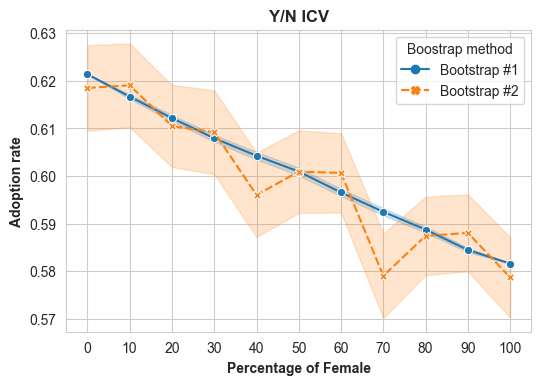

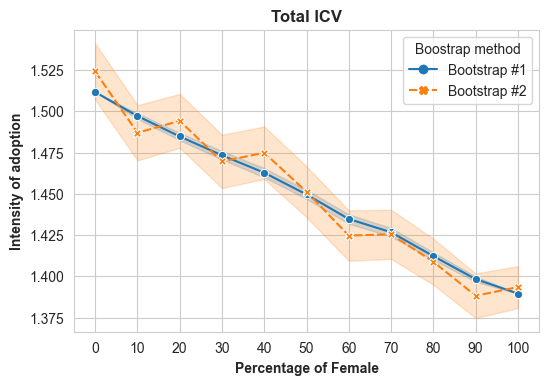

In [209]:
for y in experiment:
    fig1, ax1 = plt.subplots(dpi=100)
    sns.lineplot(ax=ax1, data=experiment[y], x="variable", y="value", 
                 hue="bootstrap", style="bootstrap",
                 markers=True, 
                 errorbar=("se", 2),)
    # ax1.set_ylim(experiment[y].min().value, ax1.get_ylim()[1])
    ax1.set_title(y, fontweight='bold')
    ax1.set_xlabel('Percentage of Female', fontweight='bold')
    ax1.set_ylabel('Adoption rate' if y == 'Y/N ICV' else 'Intensity of adoption', fontweight='bold')
    ax1.legend(title='Boostrap method')

# 2. Regressions
Run 4 regressions:  
- $Y_{husband} = X_{husband} \beta + C + \epsilon$
- $Y_{wife} = X_{wife} \beta + C + \epsilon$
- $Y_{DNA} = X_{husband} \beta + C + \epsilon$
- $Y_{DNA} = X_{wife} \beta + C + \epsilon$

In [79]:
dependent_self_reported = ['planted', 'Household_ICV']
dependent_DNA = ['DNA_planted', 'DNA_Household_ICV']

characteristic = ['ZoneID_1', 'ZoneID_3', 'ZoneID_4', # ZoneID_2 is base
                  'A03_Age', 'A05_Edu', 'Household_Size',
                  'A07_1_Main_occupatn_Farming', 'A07_1_Main_occupatn_Self_employed_off_farm', 
                  'A07_1_Main_occupatn_Other', # A07_1_Main_occupatn_Salaried_employment is base
                  'A08_fam_lab_contributn']

# J02_ percentage of household income comes from cassava? (%)
independent_income = ['J02_per_hh_inc_cassav']

# household member in coop group (0, 1)
independent_coop_member = ['Joint_Coop']

# general household credit access (0, 1)
independent_credit =  ['Credit_Access'] # Also check ['Joint_Credit']

# total household value of household assets
independent_household_asset = ['log_Total_Household_Asset_Value']

# total production asset value owned by house
independent_production_asset = ['log_Total_Production_Asset_Value']

independent = independent_income + independent_coop_member + independent_credit  + independent_household_asset + independent_production_asset


In [126]:
df_FM_test = pd.read_csv("../Output/df_FM.csv")

df_F_test = df_FM_test[df_FM_test['A02_Sex'] == 0].rename(columns=variables_dict)
df_M_test = df_FM_test[df_FM_test['A02_Sex'] == 1].rename(columns=variables_dict)

ind = list(map(lambda x: variables_dict[x], independent))
char = list(map(lambda x: variables_dict[x], characteristic))
dep_self =  list(map(lambda x: variables_dict[x], dependent_self_reported))
dep_dna = list(map(lambda x: variables_dict[x], dependent_DNA))
zones = char[:3]


results = []

for y_self, y_DNA in zip(dep_self, dep_dna):
    ##############################################
    # Self-reported regressions
    ##############################################
    # Husband 
    Y = df_M_test[y_self]
    X = sm.add_constant(df_M_test[ind + char], prepend=False)
    model_F = sm.Probit(Y,X) if y_self == 'Y/N ICV' else sm.OLS(Y,X)
    results_H_self = model_F.fit(cov_type='cluster', cov_kwds={'groups': df_M_test['ZoneID'].values}, maxiter=100, )
    results.append(results_H_self)
    
    # Wife 
    Y = df_F_test[y_self]
    X = sm.add_constant(df_F_test[ind + char], prepend=False)
    model_F = sm.Probit(Y,X) if y_self == 'Y/N ICV' else sm.OLS(Y,X)
    results_F_self = model_F.fit(cov_type='cluster', cov_kwds={'groups': df_F_test['ZoneID'].values}, maxiter=100, )
    results.append(results_F_self)

    ##############################################
    # DNA-fingerprint regressions
    ##############################################
    # Husband
    Y = df_M_test[y_DNA]
    X = sm.add_constant(df_M_test[ind + char], prepend=False)
    model_M = sm.Probit(Y,X) if y_DNA == 'DNA Y/N ICV' else sm.OLS(Y,X)
    results_H_DNA = model_M.fit(cov_type='cluster', cov_kwds={'groups': df_M_test['ZoneID'].values}, maxiter=100, )
    results.append(results_H_DNA)
    
    # Wife 
    Y = df_F_test[y_DNA]
    X = sm.add_constant(df_F_test[ind + char], prepend=False)
    model_F = sm.Probit(Y,X) if y_DNA == 'DNA Y/N ICV' else sm.OLS(Y,X)
    results_F = model_F.fit(cov_type='cluster', cov_kwds={'groups': df_F_test['ZoneID'].values}, maxiter=100, )
    results.append(results_F)


columns_dataset_level_1 = {0: 'Y/N ICV', 1: "Total ICV"}

columns_dataset_level_2 = {0: 'Husband', 1: 'Husband', 2: 'Wife', 3: 'Wife', 
                           4: 'Husband', 5: 'Husband', 6: 'Wife', 7: 'Wife'}

columns_dataset_level_3 = {0: 'Self-reported', 1: "DNA"}

summary_str  = summary_col(results, 
                  stars=True,
                  model_names=[columns_dataset_level_1[i//4] + "-" +  columns_dataset_level_2[i] + "-" + 
                               columns_dataset_level_3[i%2] for i in range(len(results))],
                  float_format='%.3f',
                  info_dict={
                      'N':lambda x: "{0:d}".format(int(x.nobs))
                  },
                  regressor_order=ind + char
                          )# .as_latex()

df_results = summary_str.tables[0]
# df_results.columns = ['DNA' if i%2==0 else 'Self-reported' for i in range(df_results.columns.shape[0])]
# print(df_results.to_latex())
df_results


Optimization terminated successfully.
         Current function value: 0.608445
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.636414
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.619998
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.614215
         Iterations 5


,Y/N ICV-Husband-Self-reported,Y/N ICV-Husband-DNA,Y/N ICV-Wife-Self-reported,Y/N ICV-Wife-DNA,Total ICV-Husband-Self-reported,Total ICV-Husband-DNA,Total ICV-Wife-Self-reported,Total ICV-Wife-DNA
Income from Cassava (%),-0.000,0.002,0.002,-0.003,0.003,0.002,0.007**,0.002
,(0.002),(0.002),(0.003),(0.003),(0.004),(0.002),(0.004),(0.006)
Joint Coop,0.166**,-0.021,0.105,-0.031,0.247**,0.137,0.238,0.062
,(0.070),(0.176),(0.088),(0.063),(0.113),(0.200),(0.162),(0.157)
Household Credit,-0.018,0.009,-0.003,0.092,0.056,-0.122***,0.094,0.054
,(0.081),(0.103),(0.112),(0.137),(0.080),(0.047),(0.090),(0.134)
Log Household Asset,0.002,0.021,0.035**,-0.026,0.006,0.044*,0.011,0.000
,(0.010),(0.017),(0.016),(0.037),(0.029),(0.023),(0.010),(0.028)
Log Total Production Asset,0.013,0.063*,-0.036*,-0.036,0.039,0.060,0.028,-0.005
,(0.043),(0.035),(0.021),(0.029),(0.093),(0.092),(0.044),(0.058)


# 3. Oaxaca-blinder decomposition

In [196]:
dependent_self_reported = ['planted', 'Household_ICV']
dependent_DNA = ['DNA_planted', 'DNA_Household_ICV']

characteristic = ['ZoneID_1', 'ZoneID_3', 'ZoneID_4', # ZoneID_2 is base
                  'A03_Age', 'A05_Edu', 'Household_Size',
                  'A07_1_Main_occupatn_Farming', 'A07_1_Main_occupatn_Self_employed_off_farm', 
                  'A07_1_Main_occupatn_Other', # A07_1_Main_occupatn_Salaried_employment is base
                  'A08_fam_lab_contributn']

# J02_ percentage of household income comes from cassava? (%)
independent_income = ['J02_per_hh_inc_cassav']

# household member in coop group (0, 1)
independent_coop_member = ['Joint_Coop']

# general household credit access (0, 1)
independent_credit =  ['Credit_Access'] # Also check ['Joint_Credit']

# total household value of household assets
independent_household_asset = ['log_Total_Household_Asset_Value']

# total production asset value owned by house
independent_production_asset = ['log_Total_Production_Asset_Value']

independent = independent_income + independent_coop_member + independent_credit  + independent_household_asset + independent_production_asset


## 3.1 Gender gap between self-reported  values

In [211]:
df_results = []

## Select the group A and B
groupA = 'F' # Female
groupB = 'M' # Male
dataset = f'{groupA}{groupB}'

for y in ['planted', 'Household_ICV']:
    group = 'A02_Sex'
    formula = f'{y} ~ ' + ' + '.join(independent) + " + " + ' + '.join(characteristic) + f' | {group} ' + \
                ' | ' + ' + '.join(characteristic[:3])
    #formula = f'{dependent} ~ ' + ' + '.join(independent)  +  f' | {group}' 
    extra = 'reg.fun = glm, family = binomial(link = "probit")' if dependent == 'planted' else ''
    
    # print(formula)
    robjects.r(f''' 
        df <- read.csv("../Output/df_{dataset}.csv")
        results <- oaxaca(formula = {formula}, data=df, {extra}, R=100)

    ''')


    results = robjects.globalenv['results']
    resulst_dict = dict(zip(results.names, results))
    resulst_dict_threefold = dict(zip(resulst_dict['threefold'].names, 
                                      list(resulst_dict['threefold'])))
    
    results_dict_y =dict(zip(resulst_dict['y'].names, resulst_dict['y']))
    print(y, '\t'
          'Group A = ', '{:.3f}'.format(results_dict_y['y.A'][0]), 
          ', Group B = ',   '{:.3f}'.format(results_dict_y['y.B'][0]), 
          ', Mean gender gap=', '{:.3f}'.format(results_dict_y['y.diff'][0])) 
    
    df_tmp = update_results(resulst_dict_threefold, independent, characteristic, base =['(Base)'], 
                            variables_dict=variables_dict)
    df_tmp.columns = pd.MultiIndex.from_product([[y], df_tmp.columns])
    df_results.append(df_tmp)
    
#print(pd.concat(df_results, axis=1).to_latex(escape=False))
pd.concat(df_results, axis=1)

planted 	Group A =  0.582 , Group B =  0.621 , Mean gender gap= -0.040
Household_ICV 	Group A =  1.390 , Group B =  1.512 , Mean gender gap= -0.122


planted                             \
                                        endowments   coefficients interaction   
Agregate decomposition                    $-0.015$       $-0.011$    $-0.014$   
                                         $(0.022)$      $(0.026)$   $(0.031)$   
Share of the gap                           37.50\%        27.50\%     35.00\%   
Detailed decomposition                                                          
constant                                   $0.000$  $-0.400 ^{*}$    $-0.000$   
                                         $(0.000)$      $(0.237)$   $(0.000)$   
Income from Cassava (%)                    $0.000$        $0.048$     $0.001$   
                                         $(0.001)$      $(0.060)$   $(0.002)$   
Joint Coop                                 $0.000$       $-0.011$    $-0.000$   
                                         $(0.001)$      $(0.011)$   $(0.002)$   
Household Credit                           $0.001$        $0.005$    $-0.001$   
                                         $(0.003)$      $(0.023)$   $(0.004)$   
Log Household Asset                       $-0.000$        $0.084$    $-0.002$   
                                         $(0.002)$      $(0.154)$   $(0.003)$   
Log Total Production Asset                $-0.001$        $0.179$    $-0.003$   
                                         $(0.002)$      $(0.186)$   $(0.004)$   
Zone 1                                     $0.000$        $0.015$     $0.000$   
                                         $(0.001)$      $(0.011)$   $(0.002)$   
Zone 3                                    $-0.000$        $0.003$     $0.000$   
                                         $(0.006)$      $(0.012)$   $(0.001)$   
Zone 4                                     $0.000$       $-0.003$    $-0.000$   
                                         $(0.003)$      $(0.009)$   $(0.001)$   
Age                                       $-0.017$       $-0.030$     $0.006$   
                                         $(0.014)$      $(0.128)$   $(0.026)$   
Education                                  $0.004$        $0.054$    $-0.008$   
                                         $(0.005)$      $(0.048)$   $(0.007)$   
Household size                            $-0.005$       $-0.029$     $0.002$   
                                         $(0.003)$      $(0.057)$   $(0.004)$   
Main occupation: Farming                  $-0.014$       $-0.082$     $0.014$   
                                         $(0.011)$      $(0.089)$   $(0.015)$   
Main occupation: Self employed off farm    $0.002$       $-0.002$    $-0.002$   
                                         $(0.010)$      $(0.013)$   $(0.013)$   
Main occupation: Other                    $-0.000$        $0.004$     $0.001$   
                                         $(0.002)$      $(0.005)$   $(0.002)$   
Contribution to farm work                  $0.016$        $0.173$    $-0.022$   
                                         $(0.012)$      $(0.124)$   $(0.016)$   
(Base)                                     $0.000$       $-0.019$     $0.000$   
                                         $(0.002)$      $(0.015)$   $(0.002)$   

                                         Household_ICV                 \
                                            endowments   coefficients   
Agregate decomposition                         $0.009$        $0.002$   
                                             $(0.053)$      $(0.105)$   
Share of the gap                               -7.38\%        -1.64\%   
Detailed decomposition                                                  
constant                                       $0.000$  $-1.622 ^{*}$   
                                             $(0.000)$      $(0.839)$   
Income from Cassava (%)                        $0.003$       $-0.055$   
                                             $(0.005)$      $(0.215)$   
Joint Coop                                     $0.001$       $-0.019$   

## 3.2 Gender gap between self-reported  and DNA fingerprint for Wives 
(i.e., group A and B are the wives dataset, but for group B we change the dependent variable for the DNA-fingerprint).

In [212]:
df_results = []

## Select the group A and B
groupA = 'F' # Female
groupB = 'F' # Male
dataset = f'{groupA}{groupB}'

for y in ['planted', 'Household_ICV']:
    group = 'A02_Sex'
    formula = f'{y} ~ ' + ' + '.join(independent) + " + " + ' + '.join(characteristic) + f' | {group} ' + \
                ' | ' + ' + '.join(characteristic[:3])
    #formula = f'{dependent} ~ ' + ' + '.join(independent)  +  f' | {group}' 
    extra = 'reg.fun = glm, family = binomial(link = "probit")' if dependent == 'planted' else ''
    
    # print(formula)
    robjects.r(f''' 
        df <- read.csv("../Output/df_{dataset}.csv")
        results <- oaxaca(formula = {formula}, data=df, {extra}, R=100)

    ''')


    results = robjects.globalenv['results']
    resulst_dict = dict(zip(results.names, results))
    resulst_dict_threefold = dict(zip(resulst_dict['threefold'].names, 
                                      list(resulst_dict['threefold'])))
    
    results_dict_y =dict(zip(resulst_dict['y'].names, resulst_dict['y']))
    print(y, '\t'
          'Group A = ', '{:.3f}'.format(results_dict_y['y.A'][0]), 
          ', Group B = ',   '{:.3f}'.format(results_dict_y['y.B'][0]), 
          ', Mean gender gap=', '{:.3f}'.format(results_dict_y['y.diff'][0])) 
    
    df_tmp = update_results(resulst_dict_threefold, independent, characteristic, base =['(Base)'], 
                            variables_dict=variables_dict)
    df_tmp.columns = pd.MultiIndex.from_product([[y], df_tmp.columns])
    df_results.append(df_tmp)
    
#print(pd.concat(df_results, axis=1).to_latex(escape=False))
pd.concat(df_results, axis=1)

planted 	Group A =  0.582 , Group B =  0.645 , Mean gender gap= -0.063
Household_ICV 	Group A =  1.390 , Group B =  1.775 , Mean gender gap= -0.385


planted                   \
                                        endowments     coefficients   
Agregate decomposition                     $0.000$  $-0.063 ^{***}$   
                                         $(0.008)$        $(0.022)$   
Share of the gap                           -0.00\%         100.00\%   
Detailed decomposition                                                
constant                                   $0.000$   $-0.598 ^{**}$   
                                         $(0.000)$        $(0.264)$   
Income from Cassava (%)                   $-0.000$          $0.101$   
                                         $(0.002)$        $(0.070)$   
Joint Coop                                $-0.000$          $0.000$   
                                         $(0.001)$        $(0.012)$   
Household Credit                           $0.000$         $-0.010$   
                                         $(0.001)$        $(0.018)$   
Log Household Asset                       $-0.000$          $0.211$   
                                         $(0.001)$        $(0.182)$   
Log Total Production Asset                $-0.000$     $0.331 ^{*}$   
                                         $(0.001)$        $(0.190)$   
Zone 1                                    $-0.000$   $0.032 ^{***}$   
                                         $(0.001)$        $(0.012)$   
Zone 3                                    $-0.000$    $-0.018 ^{*}$   
                                         $(0.003)$        $(0.010)$   
Zone 4                                     $0.000$         $-0.005$   
                                         $(0.003)$        $(0.008)$   
Age                                        $0.000$    $-0.162 ^{*}$   
                                         $(0.004)$        $(0.097)$   
Education                                  $0.000$         $-0.013$   
                                         $(0.001)$        $(0.045)$   
Household size                            $-0.000$          $0.061$   
                                         $(0.001)$        $(0.056)$   
Main occupation: Farming                  $-0.000$          $0.011$   
                                         $(0.002)$        $(0.084)$   
Main occupation: Self employed off farm   $-0.000$          $0.005$   
                                         $(0.002)$        $(0.026)$   
Main occupation: Other                     $0.000$         $-0.003$   
                                         $(0.002)$        $(0.005)$   
Contribution to farm work                  $0.000$          $0.001$   
                                         $(0.001)$        $(0.094)$   
(Base)                                     $0.000$         $-0.007$   
                                         $(0.001)$        $(0.012)$   

                                                    Household_ICV  \
                                        interaction    endowments   
Agregate decomposition                      $0.000$       $0.000$   
                                          $(0.008)$     $(0.020)$   
Share of the gap                            -0.00\%       -0.00\%   
Detailed decomposition                                              
constant                                   $-0.000$       $0.000$   
                                          $(0.000)$     $(0.000)$   
Income from Cassava (%)                     $0.000$       $0.000$   
                                          $(0.003)$     $(0.006)$   
Joint Coop                                  $0.000$       $0.000$   
                                          $(0.001)$     $(0.004)$   
Household Credit                           $-0.000$       $0.000$   
                                          $(0.001)$     $(0.004)$   
Log Household Asset                         $0.000$       $0.000$   
                                          $(0.002)$     $(0.004)$   
Log Total Production Asset                  $0.000$      $-0.000$   
                             

## 3.3 Gender gap between self-reported  and DNA fingerprint for Husbands
(i.e., group A and B are the Husbands dataset, but for group B we change the dependent variable for the DNA-fingerprint).

In [215]:
df_results = []

## Select the group A and B
groupA = 'M' # Female
groupB = 'M' # Male
dataset = f'{groupA}{groupB}'

for y in ['planted', 'Household_ICV']:
    group = 'A02_Sex'
    formula = f'{y} ~ ' + ' + '.join(independent) + " + " + ' + '.join(characteristic) + f' | {group} ' + \
                ' | ' + ' + '.join(characteristic[:3])
    #formula = f'{dependent} ~ ' + ' + '.join(independent)  +  f' | {group}' 
    extra = 'reg.fun = glm, family = binomial(link = "probit")' if dependent == 'planted' else ''
    
    # print(formula)
    robjects.r(f''' 
        df <- read.csv("../Output/df_{dataset}.csv")
        results <- oaxaca(formula = {formula}, data=df, {extra}, R=100)

    ''')


    results = robjects.globalenv['results']
    resulst_dict = dict(zip(results.names, results))
    resulst_dict_threefold = dict(zip(resulst_dict['threefold'].names, 
                                      list(resulst_dict['threefold'])))
    
    results_dict_y =dict(zip(resulst_dict['y'].names, resulst_dict['y']))
    print(y, '\t'
          'Group A = ', '{:.3f}'.format(results_dict_y['y.A'][0]), 
          ', Group B = ',   '{:.3f}'.format(results_dict_y['y.B'][0]), 
          ', Mean gender gap=', '{:.3f}'.format(results_dict_y['y.diff'][0])) 
    
    df_tmp = update_results(resulst_dict_threefold, independent, characteristic, base =['(Base)'], 
                            variables_dict=variables_dict)
    df_tmp.columns = pd.MultiIndex.from_product([[y], df_tmp.columns])
    df_results.append(df_tmp)
    
#print(pd.concat(df_results, axis=1).to_latex(escape=False))
pd.concat(df_results, axis=1)

planted 	Group A =  0.621 , Group B =  0.645 , Mean gender gap= -0.023
Household_ICV 	Group A =  1.512 , Group B =  1.775 , Mean gender gap= -0.263


planted                  \
                                        endowments    coefficients   
Agregate decomposition                     $0.000$        $-0.023$   
                                         $(0.007)$       $(0.026)$   
Share of the gap                           -0.00\%        100.00\%   
Detailed decomposition                                               
constant                                   $0.000$        $-0.099$   
                                         $(0.000)$       $(0.255)$   
Income from Cassava (%)                    $0.000$        $-0.031$   
                                         $(0.001)$       $(0.052)$   
Joint Coop                                 $0.000$         $0.003$   
                                         $(0.001)$       $(0.011)$   
Household Credit                           $0.000$        $-0.003$   
                                         $(0.001)$       $(0.023)$   
Log Household Asset                        $0.000$        $-0.160$   
                                         $(0.002)$       $(0.201)$   
Log Total Production Asset                $-0.000$         $0.161$   
                                         $(0.001)$       $(0.170)$   
Zone 1                                    $-0.000$         $0.017$   
                                         $(0.001)$       $(0.012)$   
Zone 3                                    $-0.000$  $-0.021 ^{**}$   
                                         $(0.003)$       $(0.010)$   
Zone 4                                     $0.000$         $0.002$   
                                         $(0.003)$       $(0.009)$   
Age                                        $0.000$        $-0.041$   
                                         $(0.002)$       $(0.109)$   
Education                                  $0.000$        $-0.030$   
                                         $(0.001)$       $(0.053)$   
Household size                            $-0.000$   $0.102 ^{**}$   
                                         $(0.001)$       $(0.051)$   
Main occupation: Farming                  $-0.000$         $0.144$   
                                         $(0.002)$       $(0.100)$   
Main occupation: Self employed off farm   $-0.000$         $0.019$   
                                         $(0.003)$       $(0.015)$   
Main occupation: Other                    $-0.000$         $0.004$   
                                         $(0.002)$       $(0.005)$   
Contribution to farm work                 $-0.000$        $-0.095$   
                                         $(0.001)$       $(0.111)$   
(Base)                                     $0.000$         $0.005$   
                                         $(0.002)$       $(0.012)$   

                                                    Household_ICV  \
                                        interaction    endowments   
Agregate decomposition                      $0.000$       $0.000$   
                                          $(0.007)$     $(0.021)$   
Share of the gap                            -0.00\%       -0.00\%   
Detailed decomposition                                              
constant                                   $-0.000$       $0.000$   
                                          $(0.000)$     $(0.000)$   
Income from Cassava (%)                    $-0.000$       $0.000$   
                                          $(0.001)$     $(0.009)$   
Joint Coop                                  $0.000$       $0.000$   
                                          $(0.001)$     $(0.006)$   
Household Credit                           $-0.000$       $0.000$   
                                          $(0.002)$     $(0.003)$   
Log Household Asset                        $-0.000$       $0.000$   
                                          $(0.003)$     $(0.004)$   
Log Total Production Asset                  $0.000$       $0.000$   
                                          $(0.001)$     $(0.003)$   
